# Embeddings & Similarity Demo

This notebook demonstrates how sentence embeddings capture semantic meaning using `sentence-transformers` and how to compute similarity between sentences using cosine similarity.

We will:
1. Define 10 sentences across three topics: **Cricket**, **Cooking**, and **Cybersecurity**.
2. Generate embeddings using `all-MiniLM-L6-v2`.
3. Compute a 10×10 cosine similarity matrix and visualize it as a heatmap.
4. Query with a new sentence and find the top 2 most similar sentences from the set.

In [10]:
# Install required libraries (run once)
!pip install -q sentence-transformers matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
# Imports
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Make plots look nicer
sns.set(font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 8)

In [4]:
# Define 10 sentences across exactly 3 topics: Cricket, Cooking, Cybersecurity
sentences = [
    # Cricket
    "The batsman scored a century in the final overs.",
    "A crucial run-out changed the momentum of the match.",
    "The spinner bounced the ball sharply to take a wicket.",

    # Cooking
    "I love simmering broth for hours to build flavor.",
    "A pinch of salt can bring out the sweetness in tomatoes.",
    "Grilling vegetables adds a smoky depth to the dish.",

    # Cybersecurity
    "The team identified a vulnerability in the authentication flow.",
    "Encrypting user data at rest reduces exposure in case of a breach.",
    "A strong password policy prevents many common attacks.",
    "Regular audits help detect suspicious activity and potential intrusions."
]

len(sentences)  # sanity check

10

In [5]:
# Load the sentence-transformers model
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5313.56it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
# Generate embeddings for the sentences
embeddings = model.encode(sentences, convert_to_numpy=True)
embeddings.shape

(10, 384)

In [7]:
# Compute the 10x10 cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Display a quick summary
print(f"Similarity matrix shape: {similarity_matrix.shape}")
print(similarity_matrix[:2, :2])  # show top-left corner

Similarity matrix shape: (10, 10)
[[1.0000002  0.35550436]
 [0.35550436 1.0000002 ]]


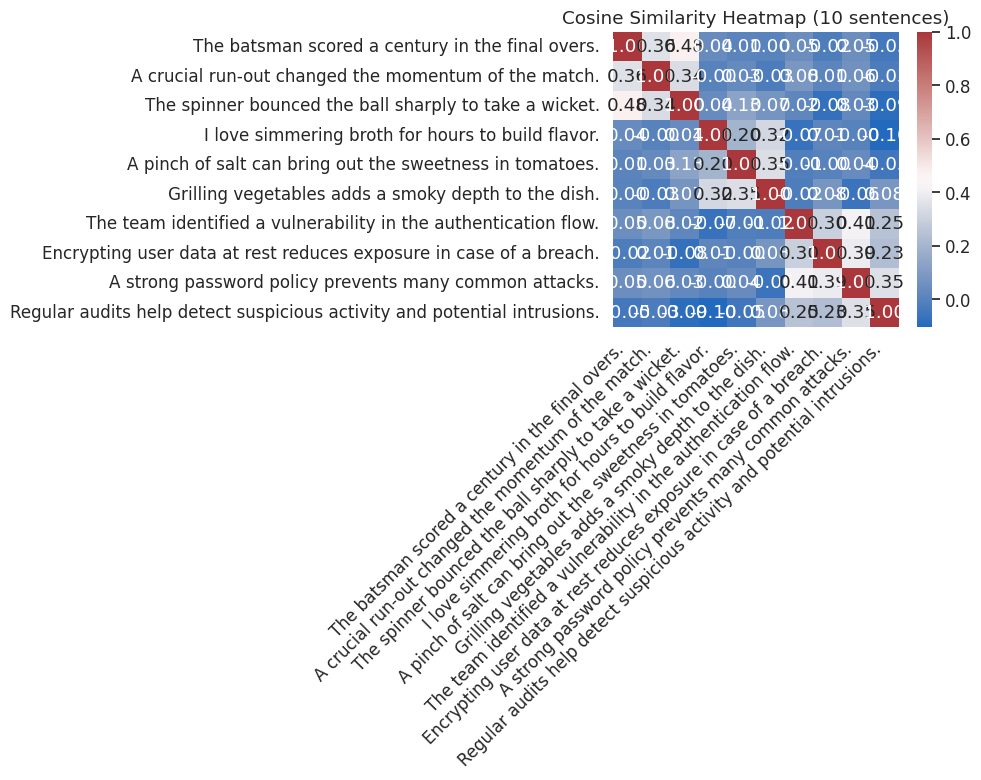

In [8]:
# Visualize the similarity matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt='.2f', cmap='vlag', xticklabels=sentences, yticklabels=sentences)
plt.title('Cosine Similarity Heatmap (10 sentences)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# Query sentence and find top 2 most similar sentences
query = "The bowler took three wickets in one over"
query_emb = model.encode([query], convert_to_numpy=True)

# Compute cosine similarity between query and each sentence in the dataset
scores = cosine_similarity(query_emb, embeddings)[0]

# Get indices of top 2 most similar sentences
top_indices = np.argsort(scores)[::-1][:2]

print(f"Query: {query}\n")
for rank, idx in enumerate(top_indices, start=1):
    print(f"Top {rank}:")
    print(f"  Sentence: {sentences[idx]}")
    print(f"  Similarity: {scores[idx]:.4f}")
    print()


Query: The bowler took three wickets in one over

Top 1:
  Sentence: The batsman scored a century in the final overs.
  Similarity: 0.6084

Top 2:
  Sentence: The spinner bounced the ball sharply to take a wicket.
  Similarity: 0.5980

